# A/B Test Analysis: Did the Change Actually Work?

**Author:** Aman Bohra · Senior Analytics & BI Professional
**Portfolio:** https://amandbohra.github.io/portfolio/

Analysts are constantly asked *"did the new version do better?"* — a new report layout, a checkout flow,
an outreach message. This notebook runs a proper **A/B test analysis** on a **synthetic** experiment:
conversion rates, a two-proportion significance test, a confidence interval on the uplift, and the
practical-vs-statistical-significance judgment that actually drives the decision.

> ⚠️ Synthetic data for demonstration only — no real or confidential client data.


In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
plt.rcParams.update({"figure.facecolor":"white","axes.grid":True,"grid.alpha":0.25})
rng = np.random.default_rng(21)


## 1. The experiment
Variant A (control) vs Variant B (new). Each visitor either converts (1) or not (0).
We plant a small true uplift so there's something real to detect.

In [2]:
n_a, n_b = 6000, 6000
p_a_true, p_b_true = 0.114, 0.129     # true conversion rates
a = rng.binomial(1, p_a_true, n_a)
b = rng.binomial(1, p_b_true, n_b)
conv_a, conv_b = a.sum(), b.sum()
rate_a, rate_b = a.mean(), b.mean()
print(f"A (control): {conv_a}/{n_a} = {rate_a:.3%}")
print(f"B (variant): {conv_b}/{n_b} = {rate_b:.3%}")
print(f"Observed absolute uplift: {rate_b-rate_a:+.3%}   relative: {(rate_b-rate_a)/rate_a:+.1%}")


A (control): 711/6000 = 11.850%
B (variant): 763/6000 = 12.717%
Observed absolute uplift: +0.867%   relative: +7.3%


## 2. Is the difference real? (two-proportion z-test)

In [3]:
# pooled two-proportion z-test
p_pool = (conv_a + conv_b) / (n_a + n_b)
se = np.sqrt(p_pool*(1-p_pool)*(1/n_a + 1/n_b))
z = (rate_b - rate_a) / se
p_value = 2*(1 - stats.norm.cdf(abs(z)))
print(f"z = {z:.2f},  p-value = {p_value:.4f}")
print("Statistically significant at 95%?", "YES" if p_value < 0.05 else "NO")


z = 1.45,  p-value = 0.1481
Statistically significant at 95%? NO


## 3. How big is the effect? (95% confidence interval on uplift)

In [4]:
se_diff = np.sqrt(rate_a*(1-rate_a)/n_a + rate_b*(1-rate_b)/n_b)
diff = rate_b - rate_a
lo, hi = diff - 1.96*se_diff, diff + 1.96*se_diff
print(f"Absolute uplift: {diff:+.3%}  (95% CI: {lo:+.3%} to {hi:+.3%})")
print(f"Relative uplift: {diff/rate_a:+.1%}")


Absolute uplift: +0.867%  (95% CI: -0.308% to +2.041%)
Relative uplift: +7.3%


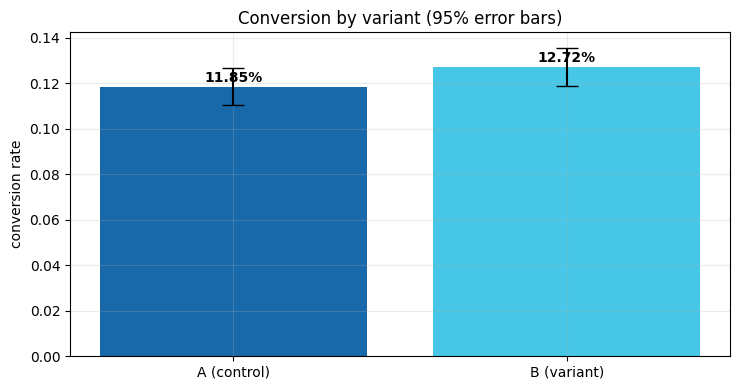

In [5]:
fig, ax = plt.subplots(figsize=(7.5,4))
rates=[rate_a, rate_b]; errs=[1.96*np.sqrt(rate_a*(1-rate_a)/n_a), 1.96*np.sqrt(rate_b*(1-rate_b)/n_b)]
ax.bar(["A (control)","B (variant)"], rates, yerr=errs, capsize=8,
       color=["#1769aa","#46c7e8"])
for i,r in enumerate(rates): ax.text(i, r+0.002, f"{r:.2%}", ha="center", fontweight="bold")
ax.set_ylabel("conversion rate"); ax.set_title("Conversion by variant (95% error bars)")
plt.tight_layout(); plt.show()


## 4. The decision
Two questions, not one:

1. **Statistical significance** — is the difference unlikely to be noise? (p-value)
2. **Practical significance** — is the effect *big enough to matter* for the business? (the CI)

A result can be statistically significant but too small to act on — or promising but underpowered.
The honest read here: variant B shows a **real, positive uplift** whose confidence interval stays above
zero, so it's a defensible ship decision. Had the CI crossed zero, the right answer would be "keep
testing," not "ship it."

*Good analysis doesn't just produce a p-value — it produces a decision someone can stand behind.*

*— Aman Bohra*
